In [1]:
from DataCollector import AuthController, ActivityRetriever
from Utility import ApplicationInfo
from Utility.jsonHelper import jsonHelper
from Models import ActivityCluster, User, Activity
from Attack1 import EPZSearch
from Attack2 import EPZSearch as EPZSearch2
from DataRepresentation import DataRepresentationFactory
from collections import namedtuple
from geopy.distance import distance as geopy_distance

import itertools
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import datetime
import time
import json
import os
import gpxpy.gpx
import traceback

cluster = []
dataset_path = 'Data/Syntetic'
update = False
Location = namedtuple('Location', ['y', 'x'])

existing_clusters = []

for folder in os.listdir(dataset_path)[1:3]:
    cluster_path = os.path.join(dataset_path, folder)
    cluster_file = os.path.join(cluster_path, "ActivityClusterList.json")

    if update:
        if os.path.isfile(cluster_file): os.remove(cluster_file)
        for file in os.listdir(cluster_path):
            if file.endswith(".json") or file.endswith("_EPZ.gpx"):
                os.remove(os.path.join(cluster_path, file))

    if not os.path.exists(cluster_file):
        for gpx_file in os.listdir(cluster_path):
            if gpx_file.endswith(".gpx"):
                polyline = Activity.Activity.initializeActivityFromGpx(os.path.join(cluster_path, gpx_file))
                cluster.append(polyline)

        activityClusterList = ActivityCluster.ActivityCluster.getAllClusters(cluster_path, 1600)

        for activityCluster in activityClusterList:
            ActivityCluster.ActivityCluster.addActivityClusterToJson(cluster_file, activityCluster)
            print(f"✅ Cluster {folder} created.")
    else:
        print(f"💾 Cluster {folder} already exists.")
    existing_clusters.append(cluster_file)


💾 Cluster 067 already exists.
💾 Cluster 091 already exists.


---------------------------------------------------------------------------
📍 CLUSTER 067
     🔍 Full disguise... 
        ✂️ Data/Syntetic/067/route_loc067_1.json 💾
        ✂️ Data/Syntetic/067/route_loc067_3.json 💾
        ✂️ Data/Syntetic/067/route_loc067_2.json 💾
        ✂️ Data/Syntetic/067/route_loc067_0.json 💾
        ✂️ Data/Syntetic/067/route_loc067_4.json 💾

        🔥 Real POI:   (50.045537, 19.944934)
        ⭕️ Real EPZ:   (50.044778, 19.945959), Radius 800 m

     🔍 Done. (0.0s)

     🔫 Attack 2... 
        🎯 All possible EPZ circles: 2 (center, radius)
            🔵 Center: (50.036085, 19.941070), Radius: 200 m
               <--> distance: 1087.17 m
            Possible POIs: 5
              (50.036088, 19.940779), distance from realPOI: 1092.32 m
              (50.036546, 19.940420), distance from realPOI: 1051.01 m
              (50.036347, 19.940320), distance from realPOI: 1074.32 m
              (50.036785, 19.940532), distance from realPOI: 1023.27 m
              

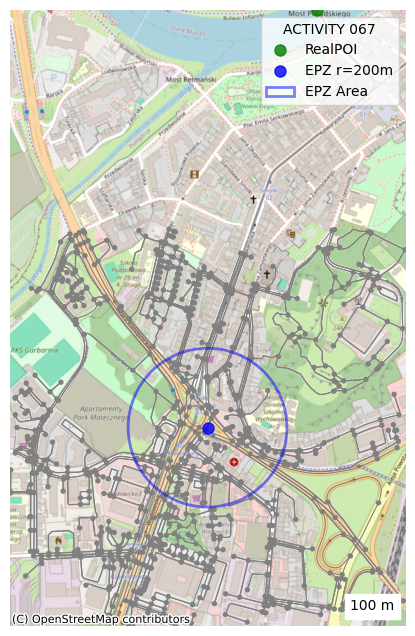

In [ ]:
def addPolylineToPlot(plt, coordinateList, label=None):
    xs, ys = zip(*coordinateList)
    plt.plot(xs[0], ys[0], marker='o', color='g', ms=5)
    if label is None:
        plt.plot(xs ,ys)
    else:
        plt.plot(xs ,ys, label=label)
    plt.plot(xs[-1], ys[-1], marker='x', color='r', ms=5)


def plotUserActivity(userId="39260108"):        
    plt.figure()
    user = initializeUser(userId)
    for activity in user.activityList:
        activity.addActivityToPlot(plt)
    plt.legend(loc="upper left")
    plt.show() 


def fullDisguiseOfActivityCluster(activityClusterPath, activityClusterId = None):
    epz_radius = 800
    activityCluster = ActivityCluster.ActivityCluster.initializeActivityClusterFromJson(activityClusterPath, activityClusterId)
    geocentricData = DataRepresentationFactory.GeocentricDataRepresentationFactory().create_data_representation()
    sphericalData = DataRepresentationFactory.SphericalDataRepresentationFactory().create_data_representation()
    cloackedCenter = dataRepresentation.generateCloackedCenter(activityCluster.center, epz_radius)
    activityCluster.updateActivityClusterCenterInJson({'cloackedCenter': cloackedCenter, 'cloackedRadius': epz_radius})
    for activityPath in activityCluster.activityPathList:
        print(f"        ✂️ {activityPath}", end='')
        with open(activityPath, 'r') as f:
            activity_data = json.load(f)

        map_data = activity_data.get('map', {})
        required_fields = ["EPZ", "EPZ+Fuzz", "CloackedEPZ", "CloackedEPZ+Fuzz", "GeocentricEPZ", "GeocentricEPZ+Fuzz", "GeocentricCloackedEPZ", "GeocentricCloackedEPZ+Fuzz"]

        if all(field in map_data and map_data[field] for field in required_fields) and not update:
            print(" 💾")
        else:
            activity = Activity.Activity.initActivityFromPath(activityPath)
            activity.completeDisguiseActivityInCluster(activityCluster.center, activityCluster.cloackedRadius, activityCluster.cloackedCenter, sphericalData, geocentricData)
            print(" ✔️")
    
    return activityCluster


def firstAttack(activityPathList, dataRepresentation, appInfo, attackType):
    epzsa = EPZSearch.EPZSearch(dataRepresentation, activityPathList, appInfo, attackType)
    epzsa.initializeAttack()
    print(f"        🎯 All possible EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.deleteEPZintersectingActivity()
    print(f"        🎯 Reduced EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.groupCloseEPZs()
    print(f"        🎯 Group close EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.deleteInformationlessEPZ()
    print(f"        🎯 Final set EPZ: {len(epzsa.possibleEPZs)}")
    epzsa.convertInLatLon()
    return epzsa.possibleEPZs


def secondAttack(activityCluster):
    epzSearch = EPZSearch2.EPZSearch(activityCluster)

    tau_converged = 10
    tau_disjoint = 1600
    epz_circles = epzSearch.epz_identification(tau_converged, tau_disjoint)

    print(f"        🎯 All possible EPZ circles: {len(epz_circles)} (center, radius)")

    possiblePOI = []
    for c in epz_circles:
    
        sensLocs = epzSearch.retriveSensitiveLocationv2(c, activityCluster.center, activityCluster.cloackedRadius, cluster_num)
        if sensLocs is not None:
            possiblePOI = possiblePOI + sensLocs


        center, radius, _ = c
        epz_center = dataRepresentation.transformToLatLon(*center)
        epz_center = list(epz_center)
        distance = geopy_distance((epz_center[0], epz_center[1]), activityCluster.center).meters
        print(f"            🔵 Center: ({epz_center[0]:.6f}, {epz_center[1]:.6f}), Radius: {round(radius, 2)} m\n               <--> distance: {distance:.2f} m")

        print(f"            Possible POIs: {len(possiblePOI)}")
        for p in possiblePOI:
            filtered_p = Location(**{k: p[k] for k in Location._fields if k in p})
            c = Location(**{'y': activityCluster.center[0], 'x': activityCluster.center[1]})
            distance_meters = geopy_distance((filtered_p.y, filtered_p.x), activityCluster.center).meters
            print(f"              ({filtered_p.y:.6f}, {filtered_p.x:.6f}), distance from realPOI: {distance_meters:.2f} m")
            # print(f"          Endpoint: {node} Distance: {distance}")

    return possiblePOI #, epzSearch.retriveSensitiveLocationThroughClusters(epz_circles[0])

################################################################################################################
##################################################### MAIN #####################################################
################################################################################################################

global appInfo
appInfo = ApplicationInfo.ApplicationInfo("Strava")
# attackType = "EPZ+Fuzz"
attackType = "EPZ"
dataRepresentation = DataRepresentationFactory.GeocentricDataRepresentationFactory().create_data_representation()
# dataRepresentation = DataRepresentationFactory.SphericalDataRepresentationFactory().create_data_representation(attackType)

for cluster in existing_clusters:
    try:
        cluster_num = cluster.strip("Data/Syntetic/").strip("/ActivityClusterList.json")
        print(f"---------------------------------------------------------------------------\n📍 CLUSTER {cluster_num}")
        now = time.time()
        print("     🔍 Full disguise... ")
        activityCluster = fullDisguiseOfActivityCluster(cluster)
        print(f"\n        🔥 Real POI:   ({activityCluster.center[0]:.6f}, {activityCluster.center[1]:.6f})")
        print(f"        ⭕️ Real EPZ:   ({activityCluster.cloackedCenter[0]:.6f}, {activityCluster.cloackedCenter[1]:.6f}), Radius {activityCluster.cloackedRadius} m")
        
        print(f"\n     🔍 Done. ({time.time()-now:.1f}s)\n")
    
        # now = time.time()
        # print("     💣 Attack 1... ")
        # possibleEPZs = firstAttack(activityCluster.activityPathList, dataRepresentation, appInfo, attackType)
        # print(f"    🏁 Done. {len(possibleEPZs)} possible EPZs found. ({time.time()-now:.1f}s)\n")
    
        now = time.time()
        print("     🔫 Attack 2... ")
        #possibleEPZs, _ = secondAttack(activityCluster)
        possibleSensitiveLocations = secondAttack(activityCluster)
        print(f"     📐 {len(possibleSensitiveLocations) if possibleSensitiveLocations is not None else 0} possible sensitive locations found.")
        for loc in possibleSensitiveLocations:
            print(f"        {loc}")
        print(f"     🏁 Done. ({time.time()-now:.1f}s)\n")
    except Exception as e:
        print(traceback.format_exc())
        continue
